# SARS-CoV-2 lineage variants around the reference genome

The 29.9 kb SARS-CoV-2 reference genome (NC_045512.2) carries 11 annotated genes. Each variant lineage differs from it at a few dozen positions: single-base changes, short deletions and one insertion. This notebook loads the reference with its gene annotations and the lineage-defining mutations of Alpha (B.1.1.7), Delta (B.1.617.2) and Omicron BA.1, then draws the resulting graph with the reference path held in the vertical center of the view.

The data files sit next to this notebook. `build_data.py` re-downloads them: the FASTA and GFF3 come from NCBI, and the mutations come from the cov-lineages constellation definitions (see the script for details).

In [1]:
import pathlib
import tempfile

import gen

DATA_DIR = pathlib.Path(".").resolve()
FASTA = DATA_DIR / "NC_045512.2.fa"
GFF3 = DATA_DIR / "NC_045512.2.gff3"
VCF = DATA_DIR / "lineages.vcf"

for path in (FASTA, GFF3, VCF):
    assert path.exists(), f"Missing: {path}"

repo = gen.Repository(tempfile.mkdtemp(prefix="gen-sarscov2-"))
repo.import_fasta(str(FASTA), sample="reference")
repo.update_with_vcf(str(VCF), reference="reference")

# Keep the eleven gene rows, leaving out the mature protein regions nested inside ORF1ab.
GENES_GFF3 = pathlib.Path(tempfile.mkdtemp(prefix="gen-sarscov2-genes-")) / "genes.gff3"
GENES_GFF3.write_text(
    "".join(
        row
        for row in GFF3.read_text().splitlines(keepends=True)
        if row.startswith("#") or row.split("\t")[2:3] == ["gene"]
    )
)
repo.import_annotations(str(GENES_GFF3), name="genes")

sequence_graphs = repo.get_sequence_graphs()
for sg in sequence_graphs:
    print(f"{sg.sample.name:15s} {sg.name}")

sg_ref = next(sg for sg in sequence_graphs if sg.sample.name == "reference")
sg_alpha = next(sg for sg in sequence_graphs if sg.sample.name == "Alpha")
sg_delta = next(sg for sg in sequence_graphs if sg.sample.name == "Delta")
sg_omicron = next(sg for sg in sequence_graphs if sg.sample.name == "Omicron_BA.1")

Alpha           NC_045512.2
Delta           NC_045512.2
reference       NC_045512.2
Omicron_BA.1    NC_045512.2


## The reference with gene annotations

`import_annotations` records the GFF3 features in the repository, and plots draw them as labeled highlights along the sequence. Only the `gene` rows are imported, which keeps the eleven genes without the mature protein regions nested inside ORF1ab.

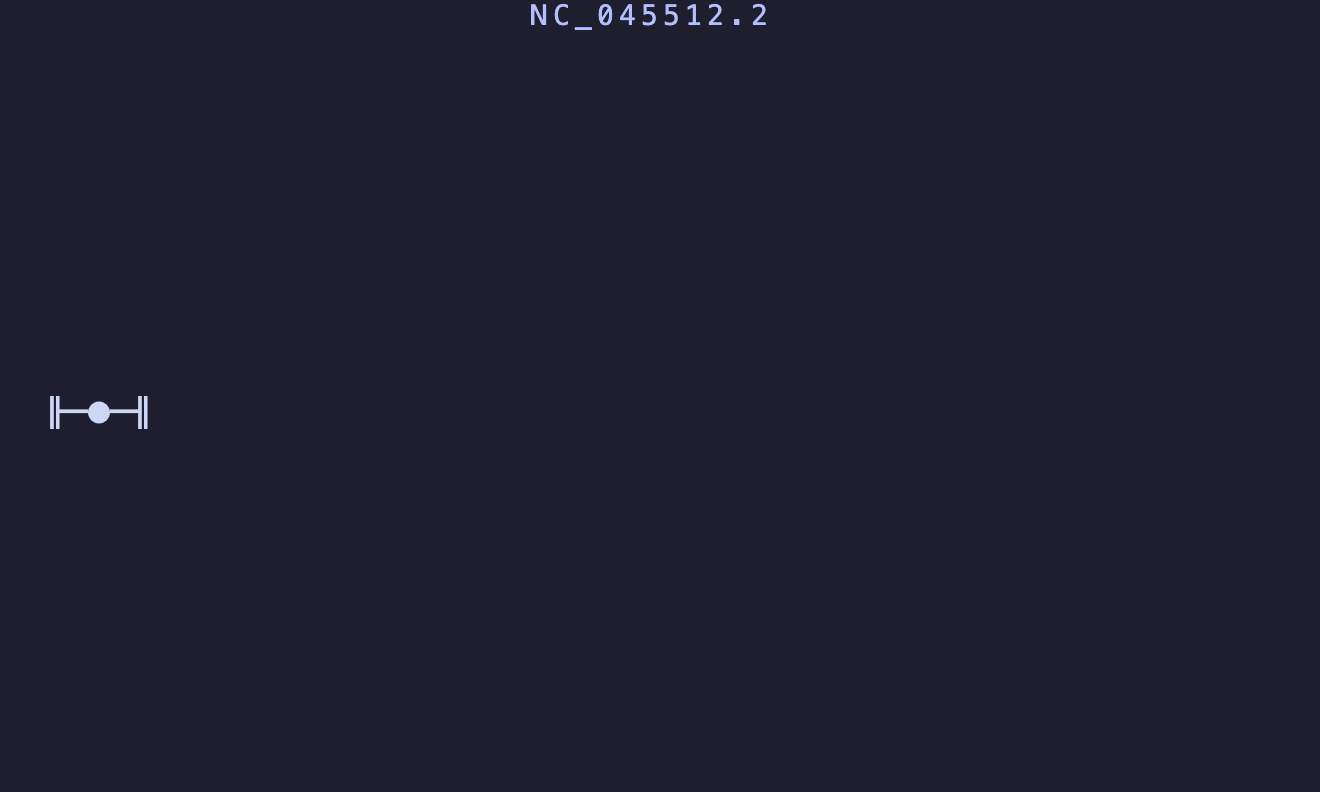

In [2]:
fig_genes = sg_ref.plot(rows=24)
fig_genes

## Omicron BA.1 against the reference

The Omicron BA.1 sample follows the reference except at its variant sites, where it takes short alternative branches. With `center_reference=True` the reference path stays on the center line of the view and variant branches open above and below it, so the reference reads as one straight line from end to end.

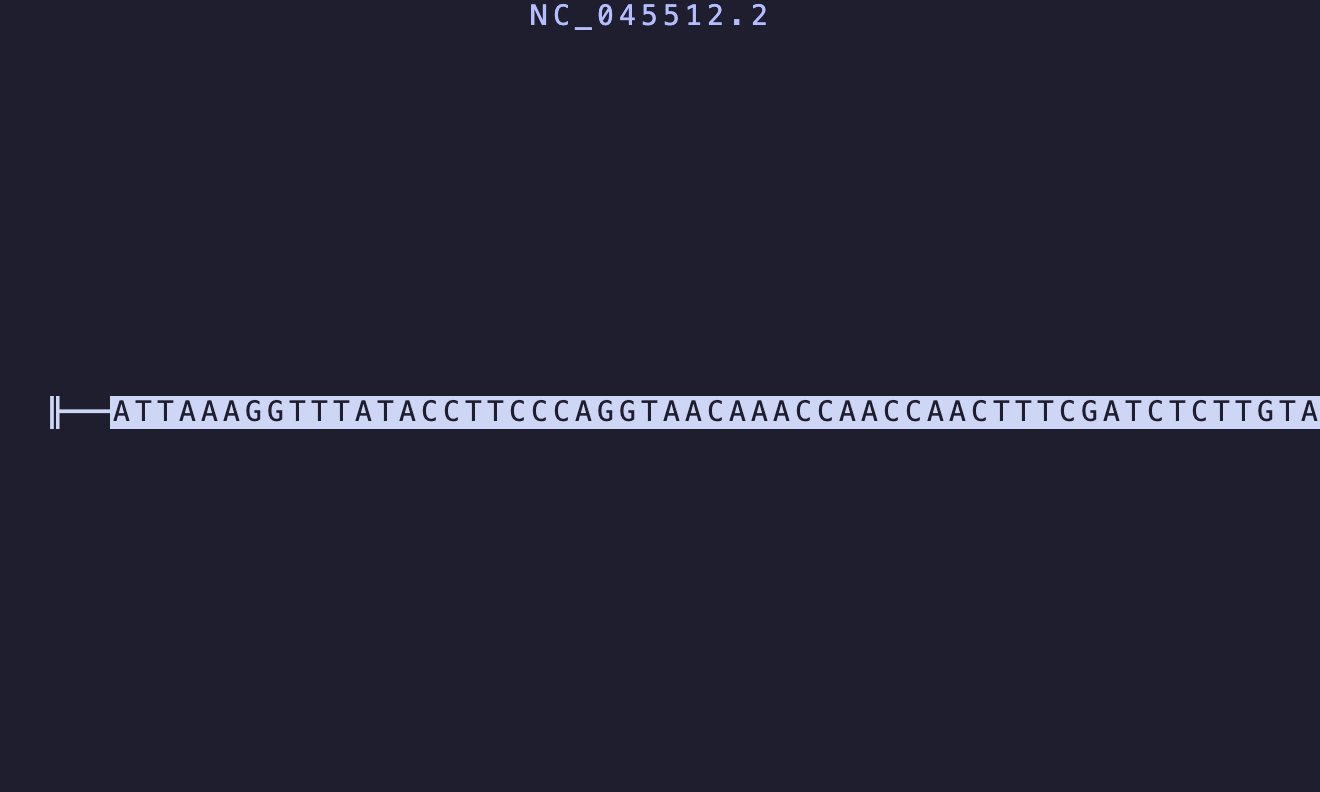

In [3]:
fig_omicron = sg_omicron.plot(rows=24, center_reference=True, show_history=True)
fig_omicron

## The spike gene

The receptor-binding domain of the spike protein is where the lineages accumulate the most changes. Searching for a 12 base stretch of reference sequence there gives a location to jump to. `center=True` places it in the middle of the view.

In [4]:
reference_sequence = "".join(FASTA.read_text().splitlines()[1:])
spike_motif = reference_sequence[23008:23020]
print(spike_motif)

spike_hits = sg_omicron.search(spike_motif)
print(f"{len(spike_hits)} match(es)")

GTTGAAGGTTTT
1 match(es)


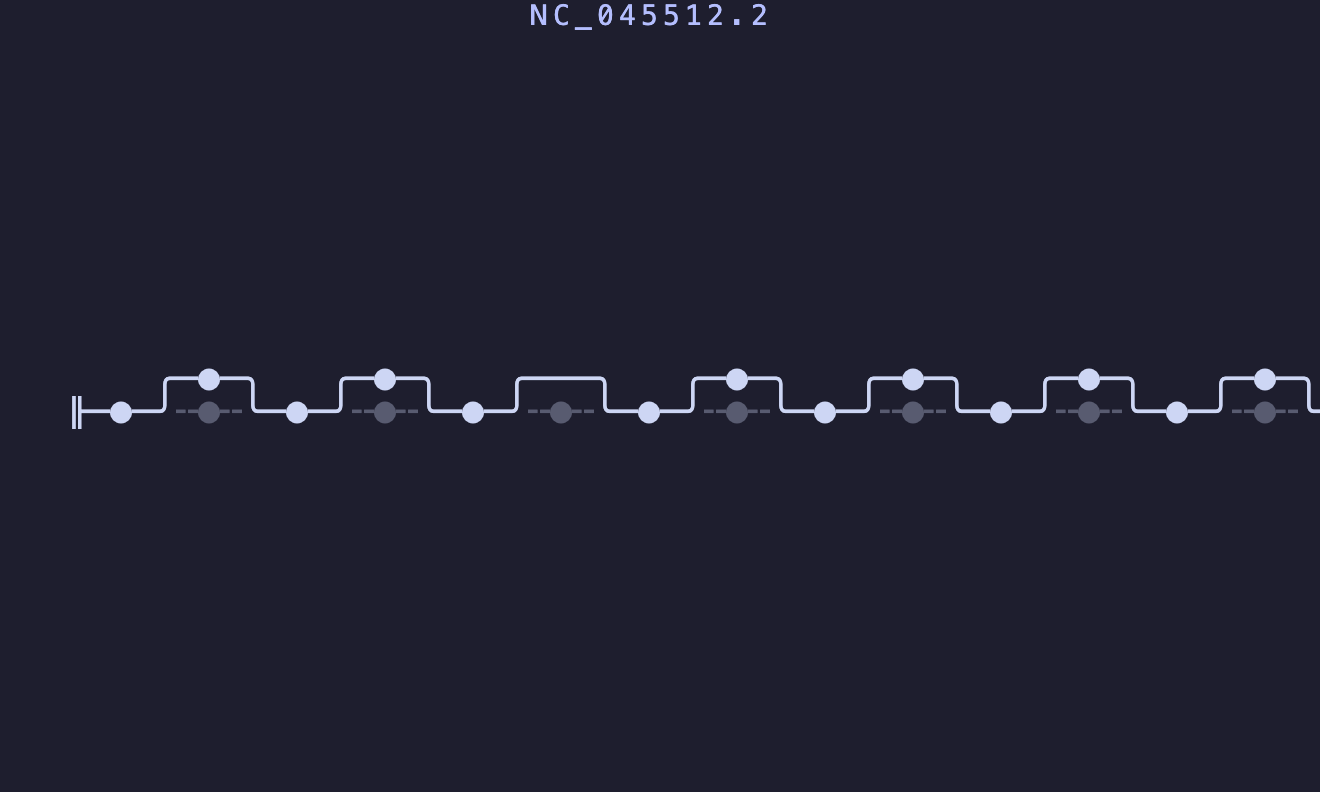

In [5]:
fig_spike = sg_omicron.plot(rows=24, center_reference=True, show_history=True)
fig_spike.go_to(spike_hits[0], center=True)
fig_spike

## Delta and Alpha in the same region

The same view for the Delta sample. Its spike changes fall at different positions from Omicron's.

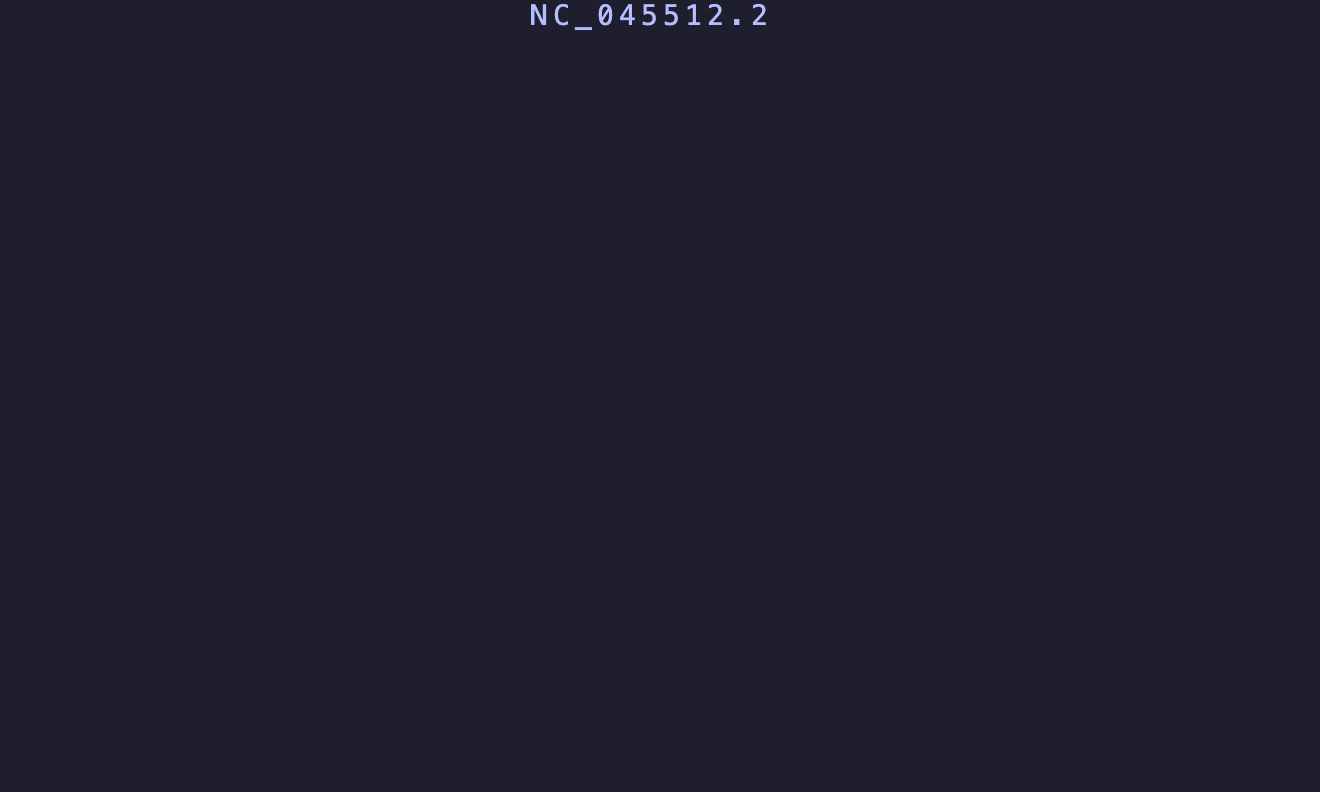

In [6]:
fig_delta = sg_delta.plot(rows=24, center_reference=True, show_history=True)
fig_delta.go_to(sg_delta.search(spike_motif)[0], center=True)
fig_delta

In [7]:
fig_alpha = sg_alpha.plot(rows=24, center_reference=True, show_history=True)
fig_alpha.go_to(sg_alpha.search(spike_motif)[0], center=True)
fig_alpha

                        nc_045512.2











─ttaccacaaaaacaacaaaagttggatggaaagtgagttcagagtttattctagtgcga










